torch.Size([1, 1, 128, 128])
torch.Size([1, 1, 128, 128])
torch.Size([1, 1, 128, 128])
torch.Size([1, 1, 128, 128])
torch.Size([1, 1, 128, 128])


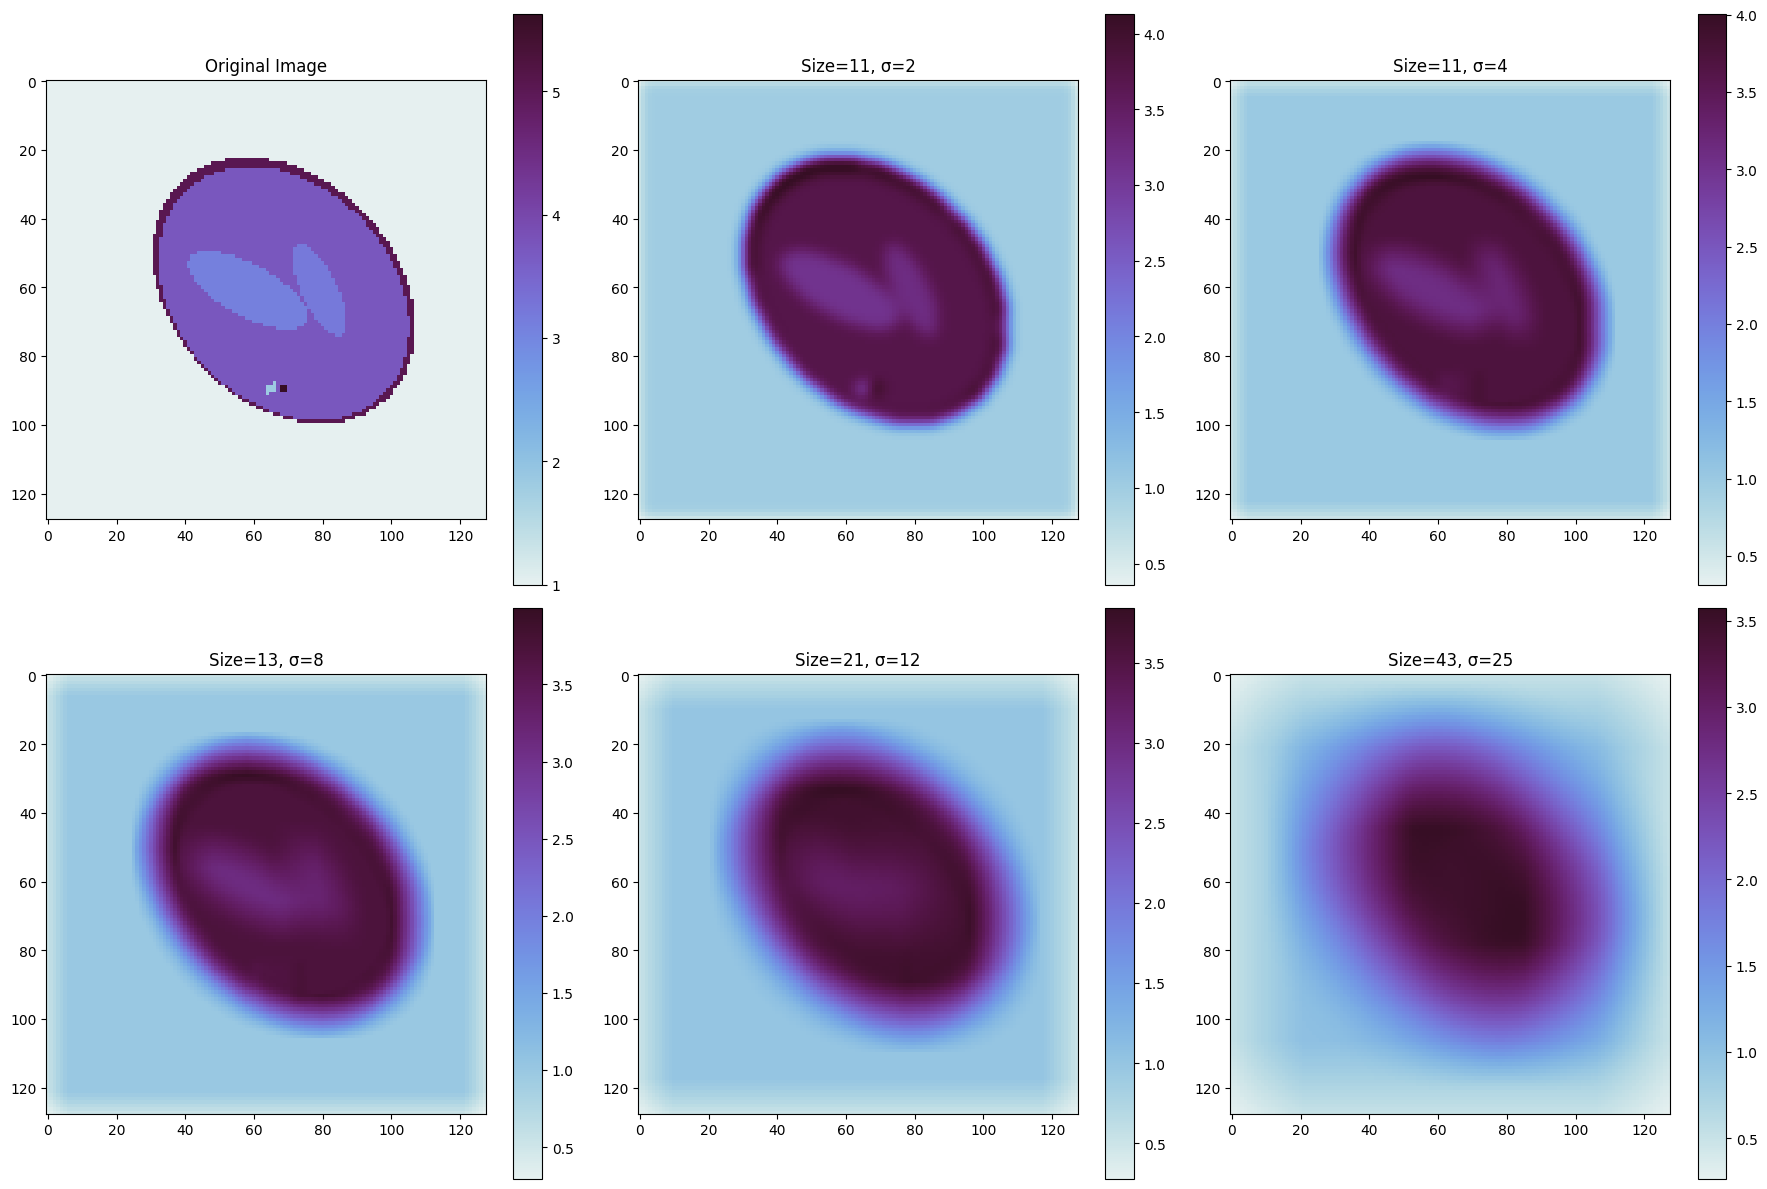

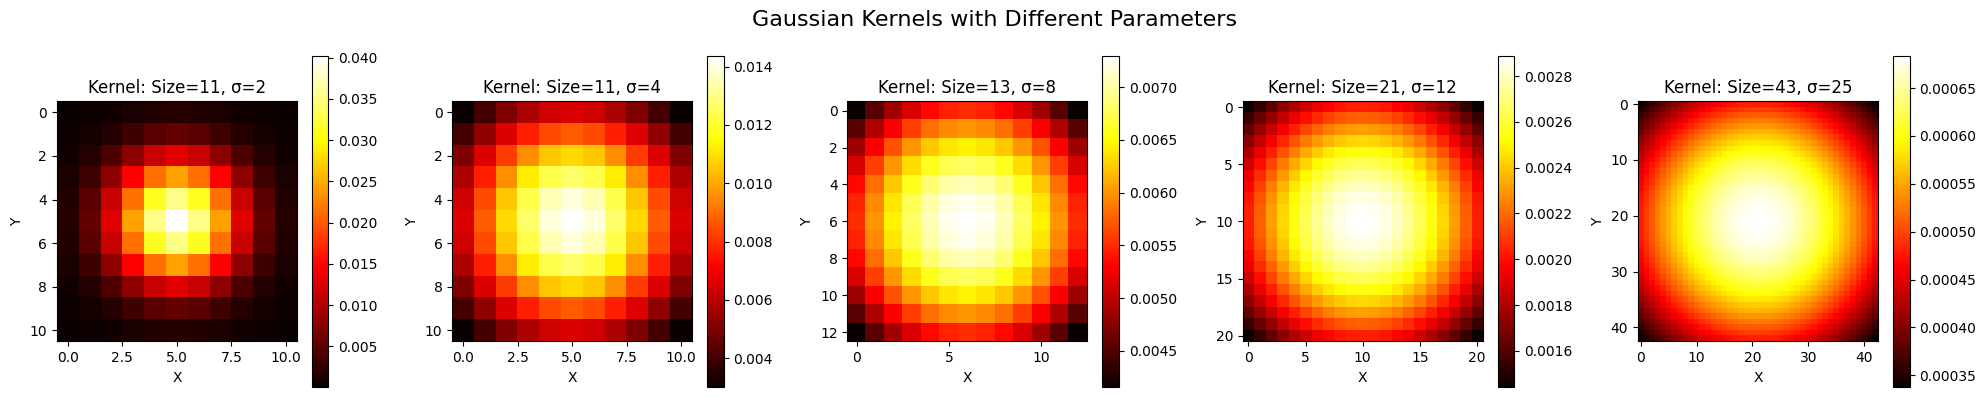

In [34]:
import torch
import cmocean as cmo
import matplotlib.pyplot as plt

# Load your data
data = torch.load('data/eit-shepp-logan-dataset-128.pt')['test']
img = data[1241]

def gaussian_kernel(size=5, sigma=2):
    """Create 2D Gaussian kernel"""
    coords = torch.arange(size) - (size-1)/2
    x, y = torch.meshgrid(coords, coords, indexing='ij')
    k = torch.exp(-(x**2 + y**2)/(2*sigma**2))
    return k / k.sum()

# Create 5 different kernel configurations
configs = [
    {'size': 11, 'sigma': 2},     # Small kernel, tight sigma
    {'size': 11, 'sigma': 4},    # Medium kernel, medium sigma
    {'size': 13, 'sigma': 8},    # Larger kernel, wider sigma
    {'size': 21, 'sigma': 12},    # Large kernel, very wide sigma
    {'size': 43, 'sigma': 25},    # Very large kernel, extremely wide sigma
]

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Original image
im = axes[0].imshow(img.squeeze(), cmap=cmo.cm.dense)
axes[0].set_title('Original Image')
fig.colorbar(im, ax=axes[0])

# Apply different blur kernels
for i, config in enumerate(configs):
    assert config['size'] % 2 == 1, "Kernel size must be odd"
    # Create kernel
    kernel = gaussian_kernel(config['size'], config['sigma']).unsqueeze(0).unsqueeze(0)
    padding = (kernel.shape[-1]) // 2
    # Apply convolution
    img_blurred = torch.nn.functional.conv2d(img.unsqueeze(0), kernel, padding=padding)
    print(img_blurred.shape)
    
    # Plot
    im = axes[i+1].imshow(img_blurred.squeeze(), cmap=cmo.cm.dense)
    axes[i+1].set_title(f'Size={config["size"]}, σ={config["sigma"]}')
    fig.colorbar(im, ax=axes[i+1])

plt.tight_layout()
plt.show()

# Also create a grid showing just the kernels themselves
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, config in enumerate(configs):
    kernel = gaussian_kernel(config['size'], config['sigma'])
    
    im = axes[i].imshow(kernel, cmap='hot')
    axes[i].set_title(f'Kernel: Size={config["size"]}, σ={config["sigma"]}')
    fig.colorbar(im, ax=axes[i])
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')

plt.suptitle('Gaussian Kernels with Different Parameters', fontsize=16)
plt.tight_layout()
plt.show()